# 🚇 서울 지하철 혼잡도 분석
**TIMLEVEN (T-XI)** · 임유정 · 전경은 · 최용우 · 최동렬 · 2026-06-26
> 운영 자원 배치를 위한 데이터 기반 혼잡 진단 — 클라이언트(가상): 서울교통공사 운영·안전팀
> 데이터 `sub_data/` — 지하철 승하차·위치 + **외부 Join**(주간인구지수·기온·강수)

## 0. 분석 개요 — SCQA
| 구분 | 내용 |
|---|---|
| **상황 (S)** | 코로나 회복기, 지하철 이용 반등 |
| **문제 (C)** | 혼잡은 역·시간·방향마다 다른데 평균으론 안 보여 자원배치 근거 부족 |
| **질문 (Q)** | 어디·언제·어느 방향이 가장 혼잡하며 자원 우선순위는? |
| **답 (A)** | 핫스팟 점수화 → 시간대별 배치 우선순위 (외부데이터로 검증) |

In [1]:
import pandas as pd, numpy as np, re, glob, os
import matplotlib.pyplot as plt, matplotlib
from scipy.stats import pearsonr
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
NAVY, RED, BLUE, CYAN, GOLD = '#1D3557', '#E63946', '#457B9D', '#0E9FBF', '#E0871E'
D = 'sub_data'
def rcsv(p, **k):
    for e in ['utf-8-sig', 'cp949', 'euc-kr']:
        try: return pd.read_csv(p, encoding=e, **k)
        except UnicodeDecodeError: continue
metro = rcsv(f'{D}/Seoul_subway_data_20210705.csv')
loc   = rcsv(f'{D}/subway_location_data.csv')
on  = [c for c in metro.columns if '승차인원' in c]
off = [c for c in metro.columns if '하차인원' in c]
print(f'지하철 {metro.shape[0]:,}행 · {metro.shape[1]}열 | 승차 {len(on)}칸 · 하차 {len(off)}칸 | {metro["사용월"].min()}~{metro["사용월"].max()}')
metro[['사용월','지하철역'] + on[:1] + off[:1]].head(3)

지하철 45,338행 · 52열 | 승차 24칸 · 하차 24칸 | 201501~202106


,사용월,지하철역,04시-05시 승차인원,04시-05시 하차인원
0,202106,동대문,715,14
1,202106,동묘앞,51,1
2,202106,서울역,654,17


## 1. 시간대 패턴 — 출퇴근 양대 피크

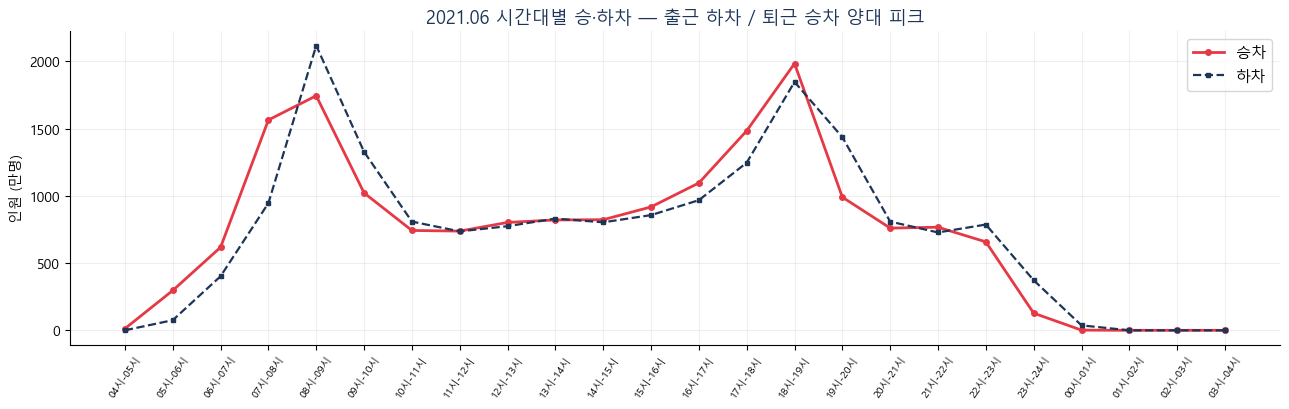

In [2]:
jun = metro[metro['사용월'] == 202106].copy()
slots = [c.replace(' 승차인원', '') for c in on]
on_s  = [jun[c].sum()/1e4 for c in on]
off_s = [jun[c].sum()/1e4 for c in off]
x = list(range(len(on)))
fig, ax = plt.subplots(figsize=(13, 4.2))
ax.plot(x, on_s, '-o', color=RED, label='승차', ms=4, lw=2)
ax.plot(x, off_s, '--s', color=NAVY, label='하차', ms=3, lw=1.6)
ax.set_xticks(x); ax.set_xticklabels(slots, rotation=55, fontsize=7.5)
ax.set_ylabel('인원 (만명)'); ax.legend(fontsize=11)
ax.set_title('2021.06 시간대별 승·하차 — 출근 하차 / 퇴근 승차 양대 피크', color=NAVY, fontsize=13)
ax.spines[['top','right']].set_visible(False); ax.grid(alpha=.2); plt.tight_layout(); plt.show()

> 출근 **08–09시 하차**, 퇴근 **18–19시 승차** 집중. 혼잡의 방향이 시간대에 따라 뒤집힌다.

## 2. 방향성 — 자치구 매핑 + 주간인구지수 Join (통계 검정)

서울 매칭역 295 · 검정대상 295 | 주간인구지수 ↔ 아침승차비율  r=-0.673, p=2.90e-40 → 유의 (귀무가설 기각)


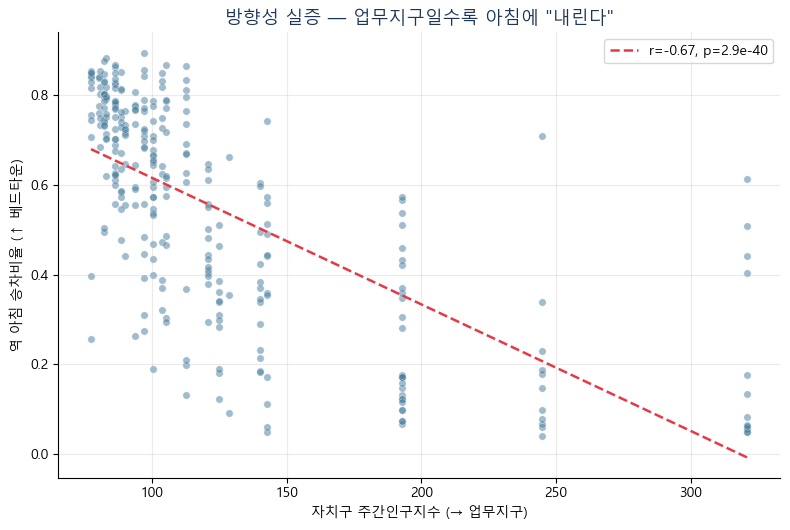

In [3]:
def keyf(x):
    return re.sub(r'역$', '', re.sub(r'\(.*?\)', '', str(x))).strip()
def get_gu(a):
    p = str(a).split()
    return p[1] if len(p) > 1 and p[0].startswith('서울') else None
loc['key'] = loc['지하철역'].apply(keyf)
loc['자치구'] = loc['주소'].apply(get_gu)
lk = loc.dropna(subset=['자치구']).drop_duplicates('key').set_index('key')['자치구']
st = jun.groupby('지하철역')[on + off].sum().reset_index()
st['key'] = st['지하철역'].apply(keyf)
st['자치구'] = st['key'].map(lk)
seoul = st[st['자치구'].notna()].copy()

xl = glob.glob(f'{D}/*.xlsx')[0]
ju = pd.read_excel(xl, header=1); ju.columns = [str(c).strip() for c in ju.columns]
GU, SEX, AGE, IDX = ju.columns[0], ju.columns[1], ju.columns[2], ju.columns[-1]
ju[GU] = ju[GU].ffill().astype(str).str.replace(r'[\s　]', '', regex=True)
ju[SEX] = ju[SEX].ffill()
g = ju[(ju[SEX] == '계') & (ju[AGE] == '합계') & (ju[GU] != '서울특별시')]
guidx = g.set_index(GU)[IDX].astype(float)
amo = [c for c in on if c[:2] in ('07','08')]
amf = [c for c in off if c[:2] in ('07','08')]
seoul['아침승차비율'] = seoul[amo].sum(1) / (seoul[amo].sum(1) + seoul[amf].sum(1))
seoul['주간인구지수'] = seoul['자치구'].map(guidx)
v = seoul[(seoul[amo].sum(1) + seoul[amf].sum(1)) > 10000].dropna(subset=['주간인구지수','아침승차비율'])
r, p = pearsonr(v['주간인구지수'], v['아침승차비율'])
print(f'서울 매칭역 {len(seoul)} · 검정대상 {len(v)} | 주간인구지수 ↔ 아침승차비율  r={r:.3f}, p={p:.2e} → ' + ('유의 (귀무가설 기각)' if p < 0.05 else '비유의'))
fig, ax = plt.subplots(figsize=(8, 5.4))
ax.scatter(v['주간인구지수'], v['아침승차비율'], c=BLUE, s=28, alpha=.5, edgecolors='white', lw=.4)
mm, bb = np.polyfit(v['주간인구지수'], v['아침승차비율'], 1)
xs = np.array([v['주간인구지수'].min(), v['주간인구지수'].max()])
ax.plot(xs, mm*xs + bb, color=RED, lw=1.8, ls='--', label=f'r={r:.2f}, p={p:.1e}')
ax.set_xlabel('자치구 주간인구지수 (→ 업무지구)'); ax.set_ylabel('역 아침 승차비율 (↑ 베드타운)')
ax.set_title('방향성 실증 — 업무지구일수록 아침에 "내린다"', color=NAVY, fontsize=13)
ax.legend(); ax.spines[['top','right']].set_visible(False); ax.grid(alpha=.25); plt.tight_layout(); plt.show()

> 주간인구지수 ↔ 아침승차비율 **음의 상관**(업무지구일수록 아침에 내림)을 외부 인구데이터로 검증. p<0.05면 통계적으로 유의.

## 3. 혼잡 핫스팟 — 출근/퇴근 Top

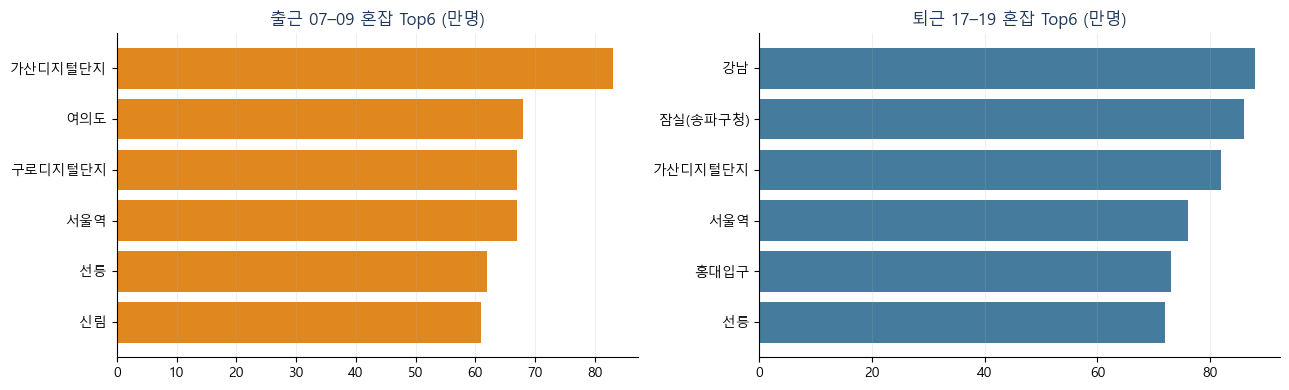

출근 1위 가산디지털단지 83만 | 퇴근 1위 강남 88만


In [4]:
def H(cs, hh): return [c for c in cs if c[:2] in hh]
jun['출근'] = jun[H(on, ('07','08'))].sum(1) + jun[H(off, ('07','08'))].sum(1)
jun['퇴근'] = jun[H(on, ('17','18'))].sum(1) + jun[H(off, ('17','18'))].sum(1)
gg = jun.groupby('지하철역')[['출근','퇴근']].sum()
am = (gg['출근'].sort_values().tail(6) / 1e4).round(0)
pm = (gg['퇴근'].sort_values().tail(6) / 1e4).round(0)
fig, axs = plt.subplots(1, 2, figsize=(13, 4))
axs[0].barh(am.index, am.values, color=GOLD); axs[0].set_title('출근 07–09 혼잡 Top6 (만명)', color=NAVY)
axs[1].barh(pm.index, pm.values, color=BLUE); axs[1].set_title('퇴근 17–19 혼잡 Top6 (만명)', color=NAVY)
for a in axs: a.spines[['top','right']].set_visible(False); a.grid(axis='x', alpha=.2)
plt.tight_layout(); plt.show()
print(f'출근 1위 {am.index[-1]} {am.iloc[-1]:.0f}만 | 퇴근 1위 {pm.index[-1]} {pm.iloc[-1]:.0f}만')

> 출근 1위 **가산디지털단지**, 퇴근 1위 **강남**. 가산은 출근 상위 + 퇴근 상위 = **양방향 슈퍼 핫스팟**.

## 4. 시계열 — 코로나·날씨 (외부 기상 Join)

시계열 78개월 | 이용 ↔ 기온 r=0.089 | 이용 ↔ 강수 r=-0.103


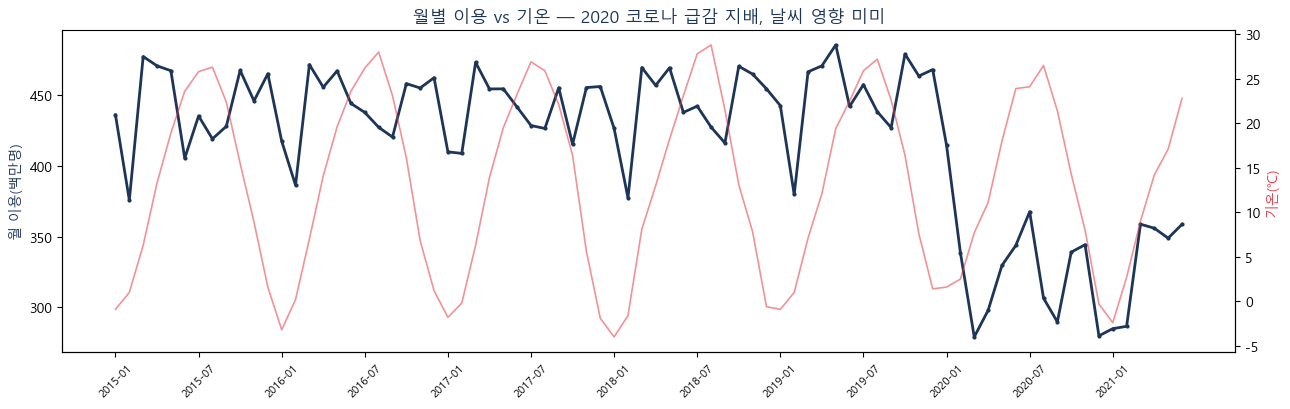

In [5]:
mall = metro.groupby('사용월')[on + off].sum().sum(1).reset_index(); mall.columns = ['사용월','이용']
mall['년월'] = pd.to_datetime(mall['사용월'].astype(str), format='%Y%m').dt.strftime('%Y-%m')
def loadw(kw):
    f = [x for x in glob.glob(f'{D}/*.csv') if kw in os.path.basename(x)][0]
    w = rcsv(f, skiprows=7); w.columns = [str(c).strip() for c in w.columns]
    w['년월'] = w.iloc[:, 0].astype(str).str.strip()
    w['val'] = pd.to_numeric(w.iloc[:, 2], errors='coerce')
    return w[['년월','val']].dropna()
m = mall.merge(loadw('기온').rename(columns={'val':'기온'}), on='년월', how='inner')
m = m.merge(loadw('강수').rename(columns={'val':'강수'}), on='년월', how='left')
print(f'시계열 {len(m)}개월 | 이용 ↔ 기온 r={m["이용"].corr(m["기온"]):.3f} | 이용 ↔ 강수 r={m["이용"].corr(m["강수"]):.3f}')
fig, ax = plt.subplots(figsize=(13, 4.2)); x = range(len(m))
ax.plot(x, m['이용']/1e6, color=NAVY, lw=2, marker='.', ms=4, label='월 이용(좌)')
ax2 = ax.twinx(); ax2.plot(x, m['기온'], color=RED, lw=1.2, alpha=.55, label='기온(우)')
step = max(1, len(m)//12); ax.set_xticks(list(x)[::step]); ax.set_xticklabels(list(m['년월'])[::step], rotation=45, fontsize=8)
ax.set_ylabel('월 이용(백만명)', color=NAVY); ax2.set_ylabel('기온(℃)', color=RED)
ax.set_title('월별 이용 vs 기온 — 2020 코로나 급감 지배, 날씨 영향 미미', color=NAVY, fontsize=12.5)
ax.spines[['top']].set_visible(False); plt.tight_layout(); plt.show()

> 2020 코로나로 급감(상관≠인과). 기온·강수 상관 미미 → **날씨는 통근에 거의 무관**, 통근 수요는 견고.

## 5. 솔루션 — 자원 배치 권고
- **출근 07–09** 가산·구로·여의도(하차) 증차·안전요원 / 신림·사당(승차) 승강장 관리
- **퇴근 17–19** 강남·잠실·고속터미널(승차) 승강장 푸시·증차
- **상시** 서울역·선릉(광역 허브) 양방향 집중 관리
- **실행 로드맵** 단기(무비용: 인력 재배치) → 중기(저비용: 배차 조정) → 장기(투자: 인프라 개선)

## 결론
혼잡 대응의 핵심은 ‘더 많은 자원’이 아니라 **‘맞는 시간 · 맞는 역 · 맞는 방향’에 두는 것**.
① 시간대(양대 피크) ② 방향성(인구지수로 검증) ③ 핫스팟(가산·강남) — 시간대별 차등 배치.